# Advanced Analytics

## Mutual Fund Analytics Capstone Project

This notebook performs advanced analytics on mutual fund datasets.

### Contents
1. Value at Risk (VaR)
2. Cohort Analysis
3. Fund Recommendation System

Author: Harshitha Sunil

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
nav = pd.read_csv("data/processed/clean_nav_history.csv")

transactions = pd.read_csv("data/processed/clean_investor_transactions.csv")

performance = pd.read_csv("data/processed/clean_scheme_performance.csv")

In [4]:
print("NAV Dataset:", nav.shape)
print("Transactions Dataset:", transactions.shape)
print("Performance Dataset:", performance.shape)

NAV Dataset: (46000, 3)
Transactions Dataset: (32778, 13)
Performance Dataset: (40, 19)


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

returns = nav["daily_return"].dropna()

print(returns.head())

1   -0.010306
2    0.012865
3   -0.011377
4   -0.001210
5   -0.008639
Name: daily_return, dtype: float64


In [6]:
var_95 = np.percentile(returns, 5)
var_99 = np.percentile(returns, 1)

print(f"95% Value at Risk (VaR): {var_95:.4%}")
print(f"99% Value at Risk (VaR): {var_99:.4%}")

95% Value at Risk (VaR): -1.6254%
99% Value at Risk (VaR): -2.5982%


In [7]:
var_df = pd.DataFrame({
    "Confidence Level": ["95%", "99%"],
    "Value at Risk": [var_95, var_99]
})

var_df.to_csv("reports/value_at_risk.csv", index=False)

print("Value at Risk saved successfully!")

Value at Risk saved successfully!


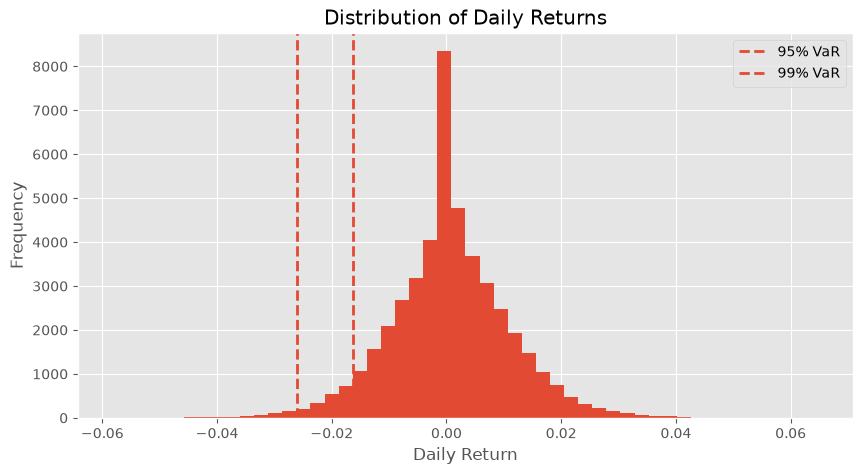

In [8]:
plt.figure(figsize=(10,5))

plt.hist(returns, bins=50)

plt.axvline(var_95, linestyle="--", linewidth=2, label="95% VaR")
plt.axvline(var_99, linestyle="--", linewidth=2, label="99% VaR")

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [9]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

transactions["CohortMonth"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.to_period("M")
)

transactions["TransactionMonth"] = (
    transactions["transaction_date"].dt.to_period("M")
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,CohortMonth,TransactionMonth
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01,2024-01
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01,2024-01


In [10]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'CohortMonth', 'TransactionMonth']


In [11]:
year_diff = (
    transactions["TransactionMonth"].dt.year
    - transactions["CohortMonth"].dt.year
)

month_diff = (
    transactions["TransactionMonth"].dt.month
    - transactions["CohortMonth"].dt.month
)

transactions["CohortIndex"] = year_diff * 12 + month_diff + 1

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,CohortMonth,TransactionMonth,CohortIndex
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01,2024-01,1
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01,2024-01,1
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01,1
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01,1
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01,2024-01,1


In [12]:
cohort_data = (
    transactions.groupby(["CohortMonth", "CohortIndex"])["investor_id"]
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="investor_id"
)

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
CohortMonth,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0,NaN
2024-03,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0,NaN,NaN
2024-04,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0,NaN,NaN,NaN
2024-05,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0,NaN,NaN,NaN,NaN
2024-06,236.0,61.0,73.0,50.0,79.0,60.0,59.0,74.0,59.0,70.0,68.0,54.0,NaN,NaN,NaN,NaN,NaN
2024-07,175.0,45.0,40.0,41.0,43.0,36.0,40.0,36.0,41.0,38.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,135.0,24.0,32.0,30.0,31.0,29.0,34.0,34.0,23.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,17.0,19.0,22.0,21.0,20.0,13.0,19.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
cohort_size = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_size, axis=0)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
CohortMonth,,,,,,,,,,,,,,,,,
2024-01,1.0,0.342422,0.359543,0.343056,0.348763,0.358275,0.346227,0.347495,0.331642,0.358909,0.344959,0.349398,0.362714,0.328472,0.340520,0.345593,0.371592
2024-02,1.0,0.359596,0.370707,0.355556,0.355556,0.353535,0.378788,0.345455,0.318182,0.351515,0.351515,0.357576,0.319192,0.350505,0.322222,0.327273,NaN
2024-03,1.0,0.312407,0.351271,0.370703,0.318386,0.312407,0.312407,0.318386,0.306428,0.321375,0.346786,0.275037,0.337818,0.345291,0.312407,NaN,NaN
2024-04,1.0,0.272109,0.310658,0.315193,0.290249,0.315193,0.340136,0.290249,0.299320,0.317460,0.292517,0.310658,0.306122,0.317460,NaN,NaN,NaN
2024-05,1.0,0.261905,0.357143,0.299320,0.258503,0.265306,0.272109,0.346939,0.302721,0.255102,0.302721,0.272109,0.289116,NaN,NaN,NaN,NaN
2024-06,1.0,0.258475,0.309322,0.211864,0.334746,0.254237,0.250000,0.313559,0.250000,0.296610,0.288136,0.228814,NaN,NaN,NaN,NaN,NaN
2024-07,1.0,0.257143,0.228571,0.234286,0.245714,0.205714,0.228571,0.205714,0.234286,0.217143,0.211429,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,1.0,0.177778,0.237037,0.222222,0.229630,0.214815,0.251852,0.251852,0.170370,0.274074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,1.0,0.170000,0.190000,0.220000,0.210000,0.200000,0.130000,0.190000,0.190000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


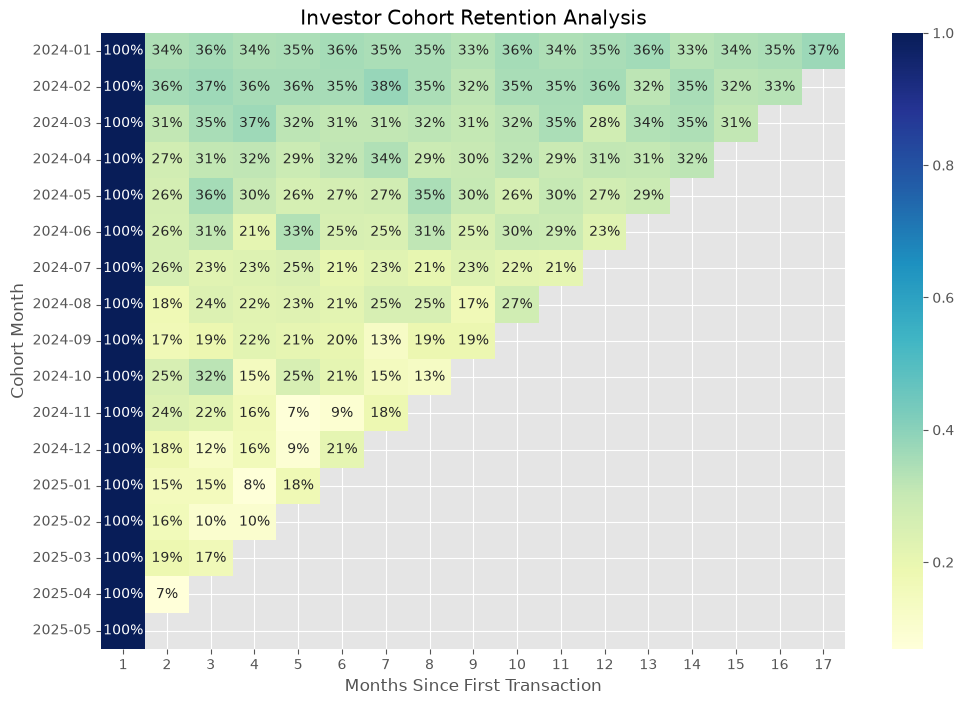

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu"
)

plt.title("Investor Cohort Retention Analysis")
plt.xlabel("Months Since First Transaction")
plt.ylabel("Cohort Month")

plt.show()

In [15]:
retention.to_csv("reports/cohort_analysis.csv")

print("Cohort Analysis saved successfully!")

Cohort Analysis saved successfully!


In [16]:
recommendation = performance.copy()

recommendation = recommendation[
    [
        "scheme_name",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "expense_ratio_pct",
        "risk_grade",
        "morningstar_rating"
    ]
]

recommendation.head()

,scheme_name,category,return_3yr_pct,sharpe_ratio,expense_ratio_pct,risk_grade,morningstar_rating
0,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,12.36,0.88,1.54,Moderate,4
1,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,11.30,0.81,0.66,Moderate,3
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,23.39,0.94,1.43,Very High,5
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,23.14,0.93,0.72,Very High,4
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52,0.77,Low,5


In [17]:
def recommend_fund(risk):

    if risk == "Low":
        return recommendation[
            recommendation["category"].isin(["Liquid","Gilt"])
        ].sort_values(
            "sharpe_ratio",
            ascending=False
        ).head(5)

    elif risk == "Medium":
        return recommendation[
            recommendation["category"].isin(["Large Cap","Flexi Cap"])
        ].sort_values(
            "return_3yr_pct",
            ascending=False
        ).head(5)

    else:
        return recommendation[
            recommendation["category"].isin(["Mid Cap","Small Cap"])
        ].sort_values(
            "return_3yr_pct",
            ascending=False
        ).head(5)

In [18]:
print("Low Risk Funds")
display(recommend_fund("Low"))

print("\nMedium Risk Funds")
display(recommend_fund("Medium"))

print("\nHigh Risk Funds")
display(recommend_fund("High"))

Low Risk Funds


,scheme_name,category,return_3yr_pct,sharpe_ratio,expense_ratio_pct,risk_grade,morningstar_rating
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68,0.74,Low,5
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18,0.60,Low,3
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14,0.79,Low,5
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52,0.77,Low,5
19,Nippon India Gilt Securities Fund - Regular - ...,Gilt,5.31,1.33,0.55,Low,4



Medium Risk Funds


,scheme_name,category,return_3yr_pct,sharpe_ratio,expense_ratio_pct,risk_grade,morningstar_rating
22,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,15.65,0.98,1.45,Moderately High,5
33,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap,15.34,0.96,1.64,Moderately High,5
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,14.84,1.06,1.55,Moderate,5
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,14.81,1.06,1.46,Moderate,5
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,14.41,1.03,0.80,Moderate,3



High Risk Funds


,scheme_name,category,return_3yr_pct,sharpe_ratio,expense_ratio_pct,risk_grade,morningstar_rating
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,23.39,0.94,1.43,Very High,5
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,23.14,0.93,0.72,Very High,4
29,ABSL Small Cap Fund - Regular - Growth,Small Cap,22.38,0.90,1.53,Very High,5
27,Axis Small Cap Fund - Regular - Growth,Small Cap,20.98,0.84,1.38,Very High,4
17,Nippon India Small Cap Fund - Regular - Growth,Small Cap,20.15,0.81,1.53,Very High,4


In [19]:
low = recommend_fund("Low")
medium = recommend_fund("Medium")
high = recommend_fund("High")

recommendations = pd.concat(
    [low, medium, high],
    keys=["Low","Medium","High"]
)

recommendations.to_csv(
    "reports/fund_recommendations.csv"
)

print("Fund recommendations saved successfully!")

Fund recommendations saved successfully!
